# 5.1 Google Trends — EDA

Descriptive analysis of Google Trends data for the 2024 US presidential election: keyword search volumes over time, candidate comparisons, state-level interest, rising queries, and correlation with Polymarket odds.

**Input:** `Data/1_Bronze/Google_Trends/trends_daily_stitched.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. All Keywords Over Time](#1-all-keywords-over-time)
- [2. Candidate Comparison](#2-candidate-comparison)
- [3. Trump–Harris Search Gap](#3-trumpharris-search-gap)
- [4. Smoothed Trends](#4-smoothed-trends)
- [5. Interest by State](#5-interest-by-state)
- [6. Rising Related Queries](#6-rising-related-queries)
- [7. Correlation with Polymarket Odds](#7-correlation-with-polymarket-odds)
- [Summary](#summary)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.insert(0, '../..')
from house_style import *
apply_style()

BRONZE_PATH = '../../Data/1_Bronze/Google Trends/'

KEYWORDS = ['trump', 'kamala', 'vance', 'walz', 'election 2024']

COLOR_MAP = {
    'trump'        : REPUBLICAN,
    'kamala'       : DEMOCRAT,
    'vance'        : '#e07b39',
    'walz'         : '#4fc3f7',
    'election 2024': NEUTRAL,
}

print('Libraries loaded, house style applied.')

Libraries loaded, house style applied.


In [2]:
df = pd.read_csv(f'{BRONZE_PATH}trends_daily_stitched.csv', index_col='date', parse_dates=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df.index.min().date()} → {df.index.max().date()}')
print(f'Missing days: {(df.index.to_series().diff().dt.days > 1).sum()}')
print(f'\nMissing values per keyword:')
print(df.isna().sum())
print(f'\nBasic statistics:')
df.describe().round(1)

Shape       : (123, 5)
Date range  : 2024-07-05 → 2024-11-04
Missing days: 0

Missing values per keyword:
trump            0
kamala           0
vance            0
walz             0
election 2024    0
dtype: int64

Basic statistics:


,trump,kamala,vance,walz,election 2024
count,123.0,123.0,123.0,123.0,123.0
mean,7.4,2.7,1.1,0.6,0.1
std,10.6,2.5,2.4,1.8,0.2
min,2.0,0.0,0.0,0.0,0.0
25%,4.0,1.2,0.0,0.0,0.0
50%,5.0,2.0,0.4,0.1,0.0
75%,7.0,3.0,1.0,0.8,0.0
max,100.0,15.0,22.0,15.0,1.0


## 1. All Keywords Over Time

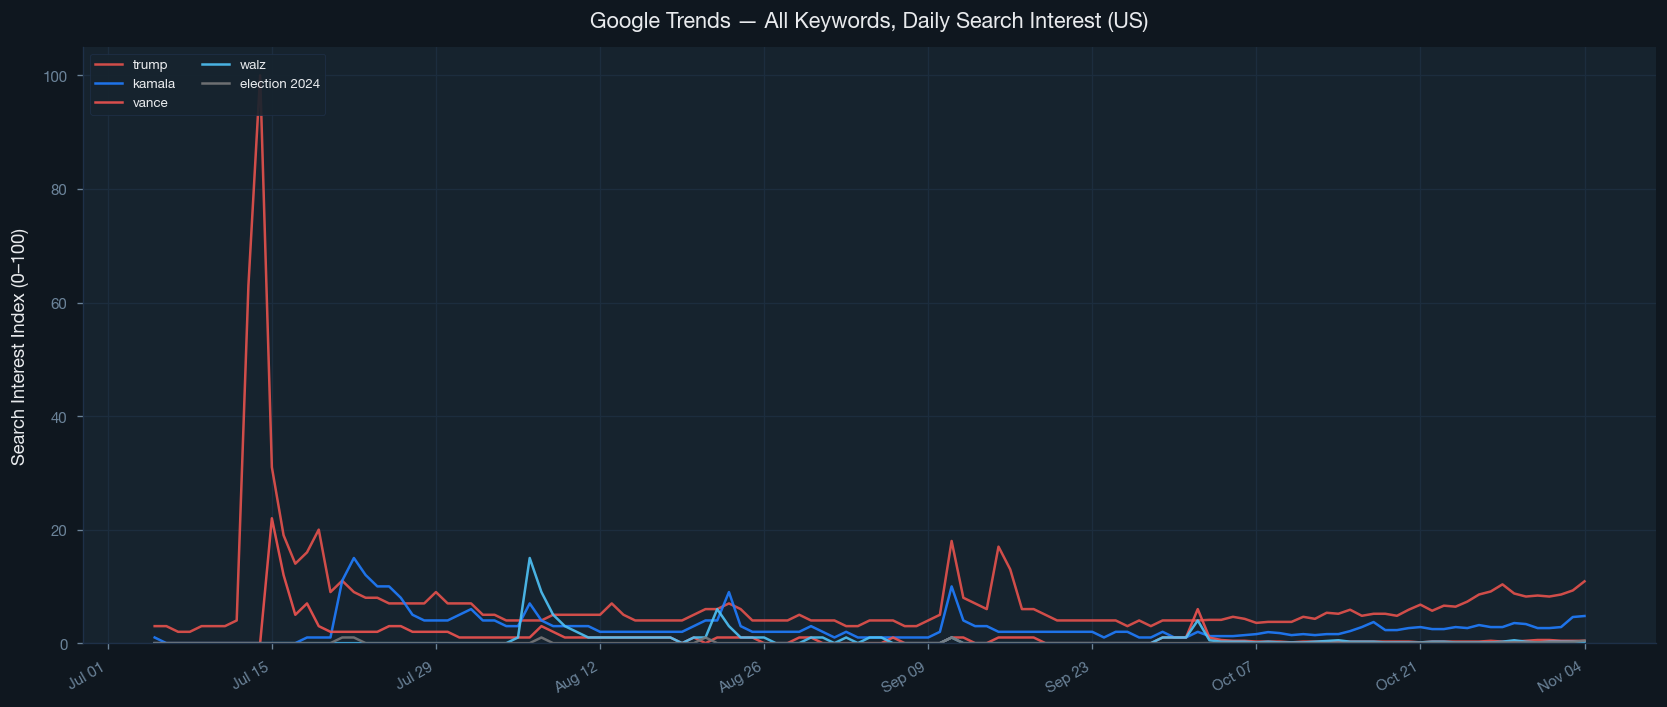

In [3]:
fig, ax = styled_fig(figsize=(14, 6))

for kw in KEYWORDS:
    ax.plot(df.index, df[kw], label=kw, color=COLOR_MAP[kw], linewidth=1.5, alpha=0.9)

style_ax(ax, title='Google Trends — All Keywords, Daily Search Interest (US)',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_all_keywords.png')
plt.show()

## 2. Candidate Comparison

Annotating major events highlights how search interest shifted in response to key moments in the campaign.

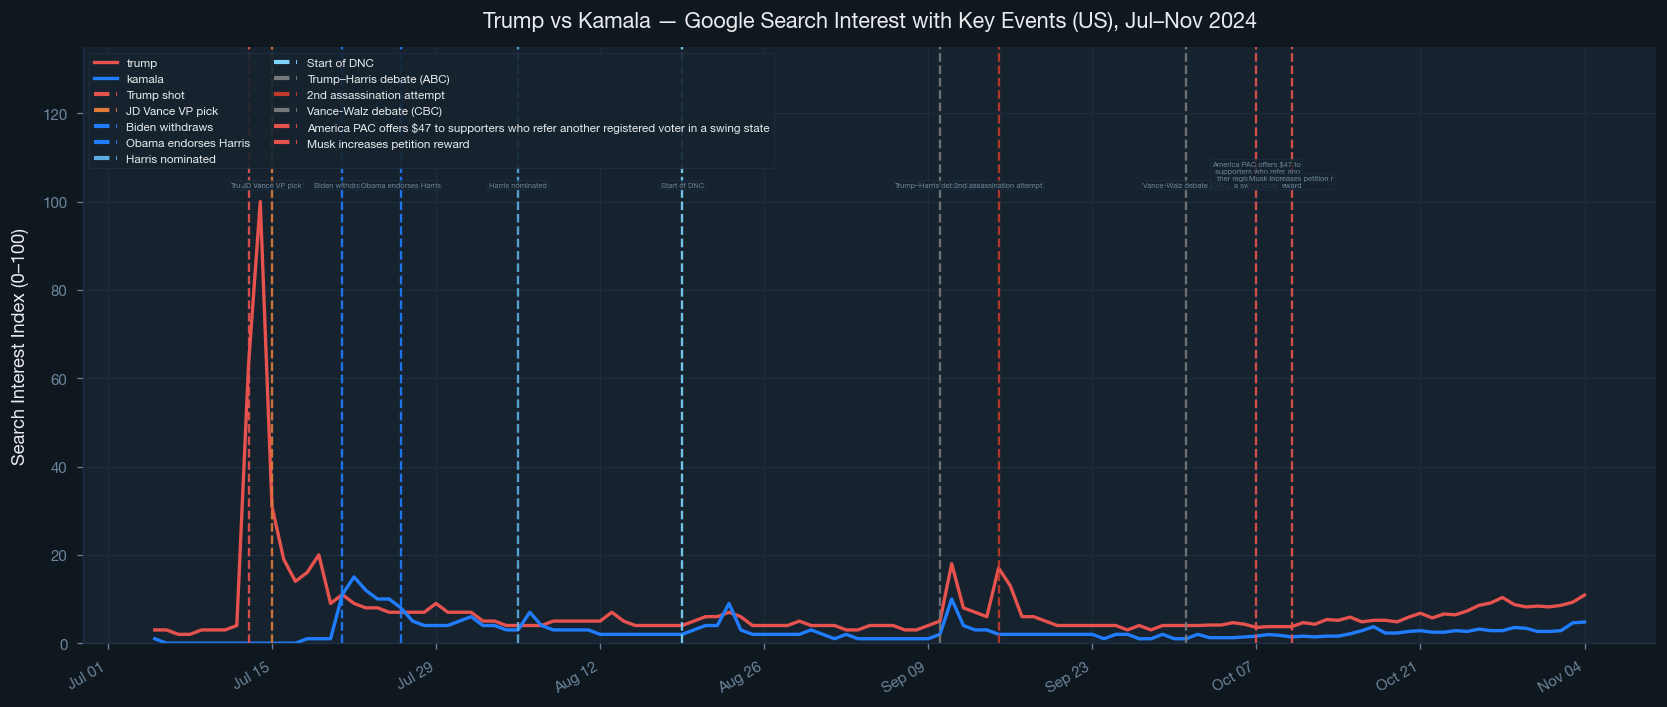

11 events defined in house_style, 11 within plot range


In [4]:
import pandas as pd

fig, ax = styled_fig(figsize=(14, 6))

ax.plot(df.index, df['trump'],  label='trump',  color=REPUBLICAN, linewidth=2)
ax.plot(df.index, df['kamala'], label='kamala', color=DEMOCRAT,   linewidth=2)

# Draw event lines using house_style EVENTS
add_events(ax)

# Annotate each event label at top of plot
for lbl, date_str, color in EVENTS:
    d = pd.Timestamp(date_str)
    if df.index.min() <= d <= df.index.max():
        short_lbl = '\n'.join([lbl[i:i+25] for i in range(0, len(lbl), 25)])
        ax.text(d, 103, short_lbl, fontsize=4.5, color=TEXT_MUTED,
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=BG_PANEL,
                          edgecolor=SPINE_COLOR, alpha=0.8))

style_ax(ax,
         title='Trump vs Kamala — Google Search Interest with Key Events (US), Jul–Nov 2024',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')

# Candidate lines legend + event legend
candidate_handles, candidate_labels = ax.get_legend_handles_labels()
event_handles = event_legend_handles()
ax.legend(candidate_handles + event_handles,
          candidate_labels + [h.get_label() for h in event_handles],
          loc='upper left', fontsize=7, ncol=2)
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_candidates_annotated.png')
plt.show()

print(f'{len(EVENTS)} events defined in house_style, '
      f'{sum(df.index.min() <= pd.Timestamp(d) <= df.index.max() for _, d, _ in EVENTS)} within plot range')

## 3. Trump–Harris Search Gap

Positive values = Trump searched more. Negative = Kamala searched more. Shows daily search dominance.

Trump leads in search: 92.7% of days
Kamala leads in search: 7.3% of days
Mean gap: 4.7


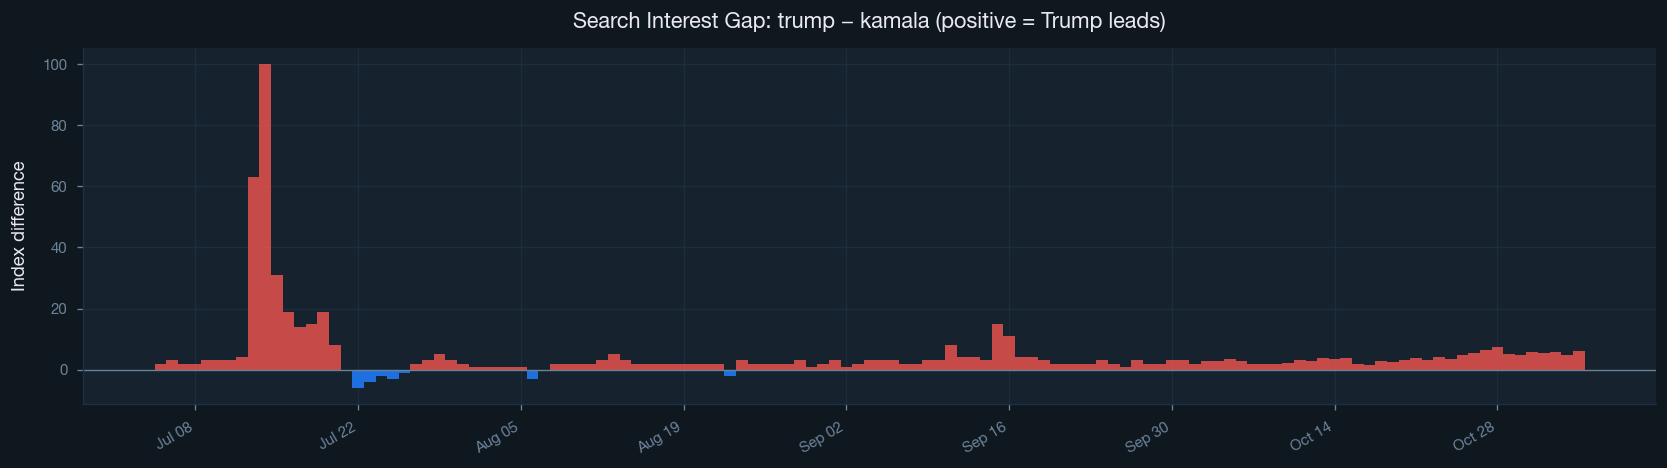

In [5]:
gap = df['trump'] - df['kamala']

fig, ax = styled_fig(figsize=(14, 4))

ax.bar(df.index, gap,
       color=[REPUBLICAN if v >= 0 else DEMOCRAT for v in gap],
       width=1, alpha=0.85)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8)

style_ax(ax,
         title='Search Interest Gap: trump − kamala (positive = Trump leads)',
         ylabel='Index difference')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')

pct_trump_leads = (gap > 0).mean() * 100
print(f'Trump leads in search: {pct_trump_leads:.1f}% of days')
print(f'Kamala leads in search: {100-pct_trump_leads:.1f}% of days')
print(f'Mean gap: {gap.mean():.1f}')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_search_gap.png')
plt.show()

## 4. Smoothed Trends

7-day rolling average to reduce day-of-week noise.

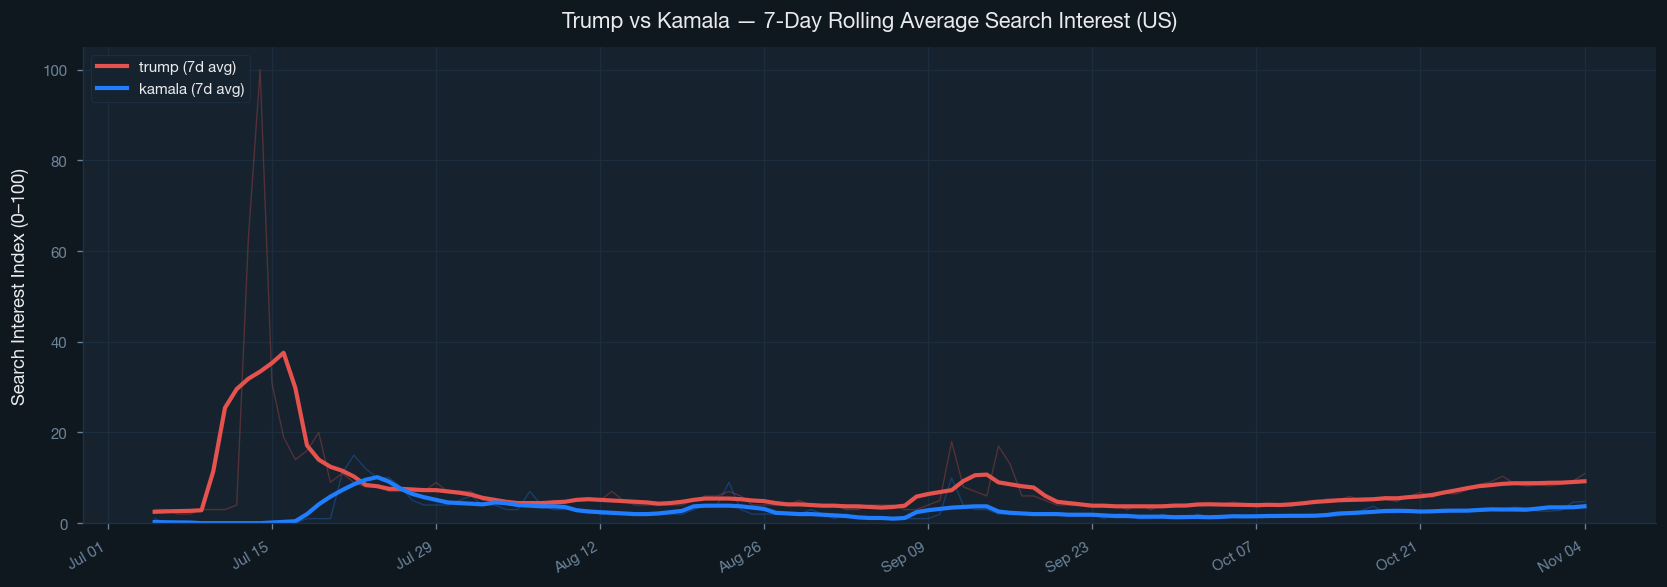

In [6]:
df_roll = df[['trump', 'kamala']].rolling(7, min_periods=4, center=True).mean()

fig, ax = styled_fig(figsize=(14, 5))

# Raw (faded)
ax.plot(df.index, df['trump'],  color=REPUBLICAN, linewidth=0.8, alpha=0.3)
ax.plot(df.index, df['kamala'], color=DEMOCRAT,   linewidth=0.8, alpha=0.3)

# Smoothed
ax.plot(df_roll.index, df_roll['trump'],  label='trump (7d avg)',  color=REPUBLICAN, linewidth=2.5)
ax.plot(df_roll.index, df_roll['kamala'], label='kamala (7d avg)', color=DEMOCRAT,   linewidth=2.5)

style_ax(ax,
         title='Trump vs Kamala — 7-Day Rolling Average Search Interest (US)',
         ylabel='Search Interest Index (0–100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_rolling_avg.png')
plt.show()

## 5. Interest by State

Top states per candidate based on relative search interest.

In [7]:
df_states = pd.read_csv(f'{BRONZE_PATH}trends_by_state.csv', index_col=0)
print(f'States data shape: {df_states.shape}')
df_states.head()

States data shape: (51, 5)


,trump,kamala,vance,walz,election 2024
geoName,,,,,
Alabama,59,23,10,5,3
Alaska,62,20,8,5,5
Arizona,60,23,8,5,4
Arkansas,59,22,9,5,5
California,58,24,8,6,4


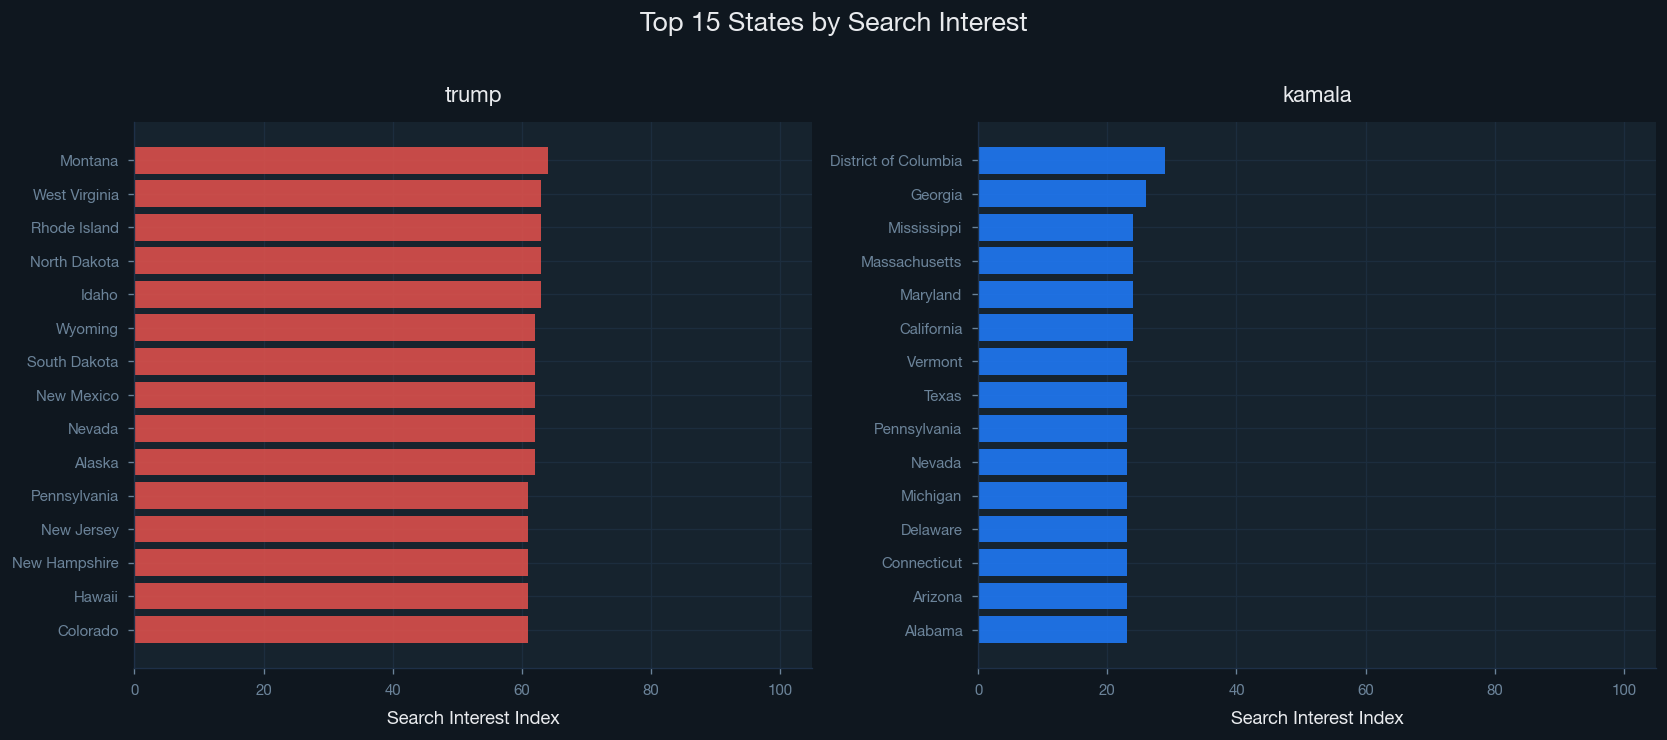

In [8]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(14, 6),
                       title='Top 15 States by Search Interest')

for ax, (candidate, color) in zip(axes, [('trump', REPUBLICAN), ('kamala', DEMOCRAT)]):
    if candidate not in df_states.columns:
        ax.text(0.5, 0.5, f'{candidate} not in data', transform=ax.transAxes,
                ha='center', color=TEXT_MUTED)
        continue
    top15 = df_states[candidate].nlargest(15).sort_values()
    ax.barh(top15.index, top15.values, color=color, alpha=0.85)
    style_ax(ax, title=candidate, xlabel='Search Interest Index', grid_axis='x')
    ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_states_top15.png')
plt.show()

## 6. Rising Related Queries

Trump vs Harris: which related queries spiked most during the campaign.

In [9]:
import os

for kw in KEYWORDS:
    safe_name = kw.replace(' ', '_').lower()
    path_rising = f'{BRONZE_PATH}related_queries_{safe_name}_rising.csv'
    if not os.path.exists(path_rising):
        print(f'File not found: {path_rising}')
        continue
    rising = pd.read_csv(path_rising).head(15)
    if rising.empty:
        print(f'No rising queries for {kw}')
        continue

    fig, ax = styled_fig(figsize=(10, 5))
    ax.barh(rising['query'], rising['value'], color=COLOR_MAP.get(kw, NEUTRAL), alpha=0.85)
    style_ax(ax, title=f'Top Rising Queries — "{kw}"',
             xlabel='Breakout value', grid_axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{BRONZE_PATH}plot_rising_queries_{safe_name}.png')
    plt.show()

File not found: ../../Data/1_Bronze/Google_Trends/related_queries_trump_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_kamala_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_vance_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_walz_rising.csv
File not found: ../../Data/1_Bronze/Google_Trends/related_queries_election_2024_rising.csv


## 7. Correlation with Polymarket Odds

Quick check: do Google search spikes correlate with prediction market movements?

In [10]:
POLY_PATH = '../../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv'

df_poly = pd.read_csv(POLY_PATH, parse_dates=['date']).set_index('date').sort_index()
df_poly.columns = ['trump_price', 'harris_price']

print(f'Polymarket shape : {df_poly.shape}')
print(f'Date range       : {df_poly.index.min().date()} → {df_poly.index.max().date()}')
df_poly.head()

Polymarket shape : (128, 2)
Date range       : 2024-07-01 → 2024-11-05


,trump_price,harris_price
date,,
2024-07-01,66.0,4.45
2024-07-02,65.0,9.65
2024-07-03,61.5,15.50
2024-07-04,60.5,20.10
2024-07-05,60.5,15.95


Merged shape: (123, 4)

Correlation matrix:
              trump  kamala  trump_price  harris_price
trump         1.000  -0.055        0.412        -0.460
kamala       -0.055   1.000        0.080         0.140
trump_price   0.412   0.080        1.000        -0.847
harris_price -0.460   0.140       -0.847         1.000


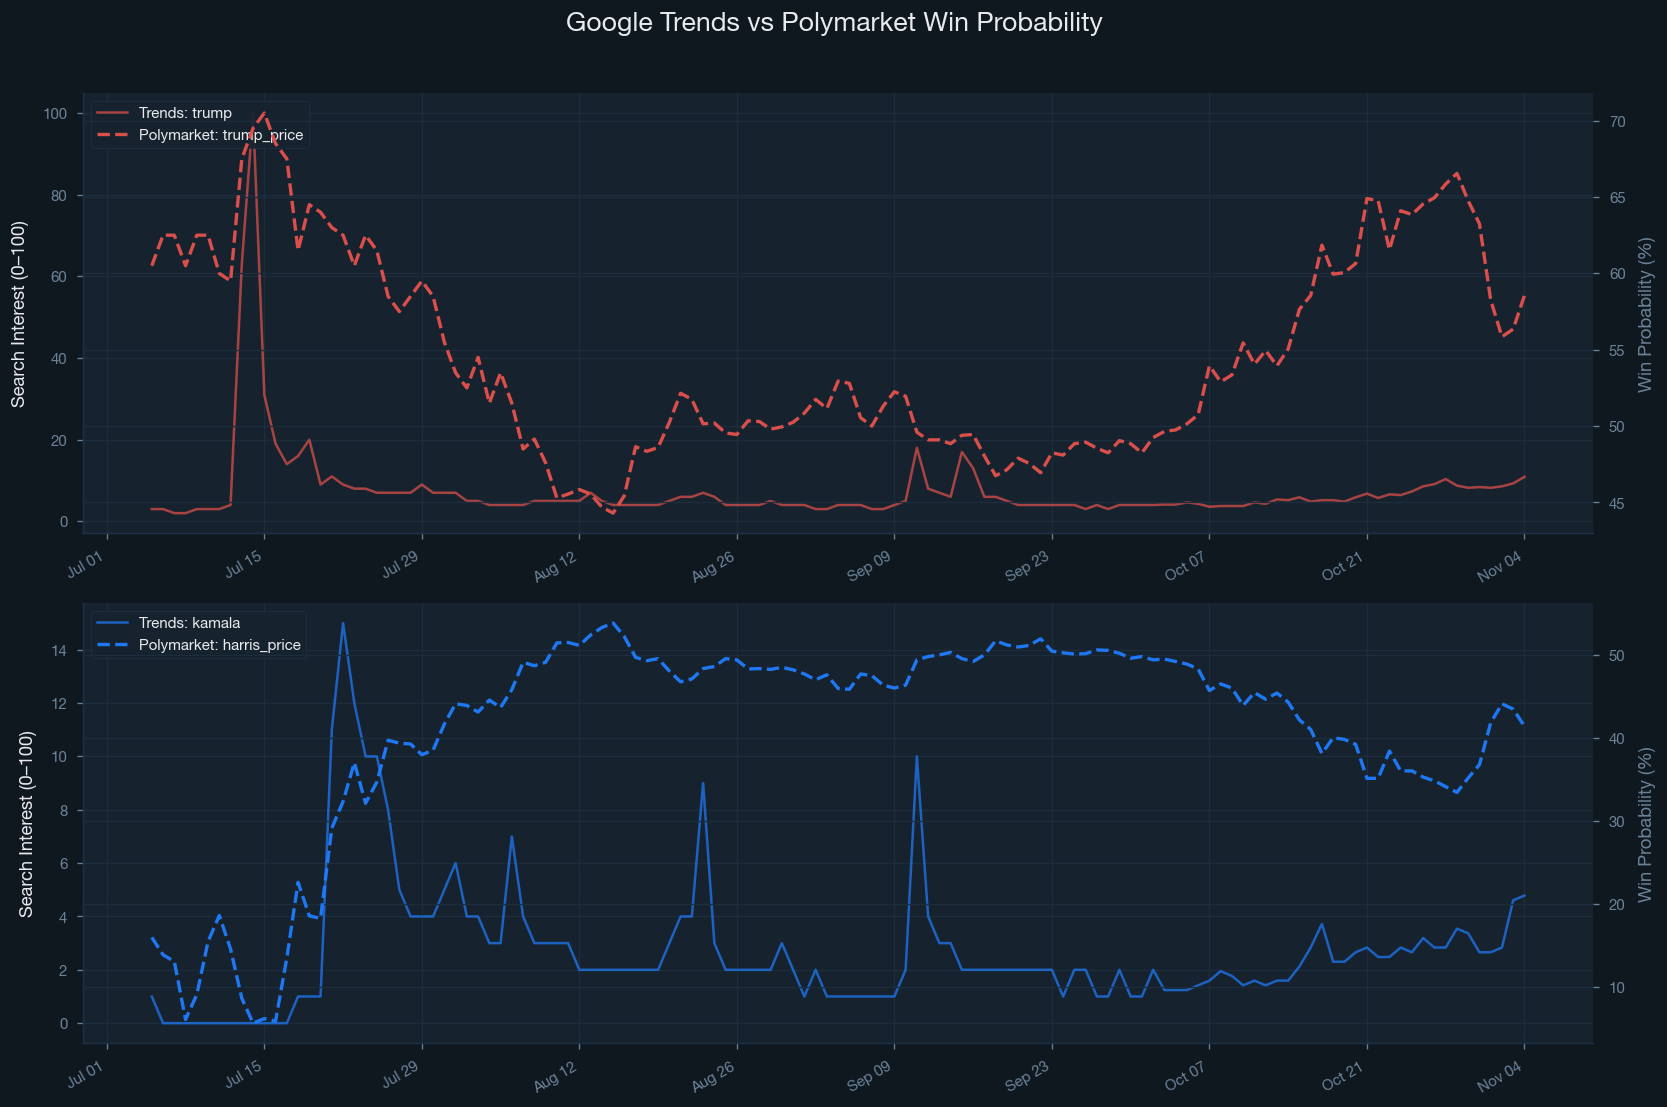

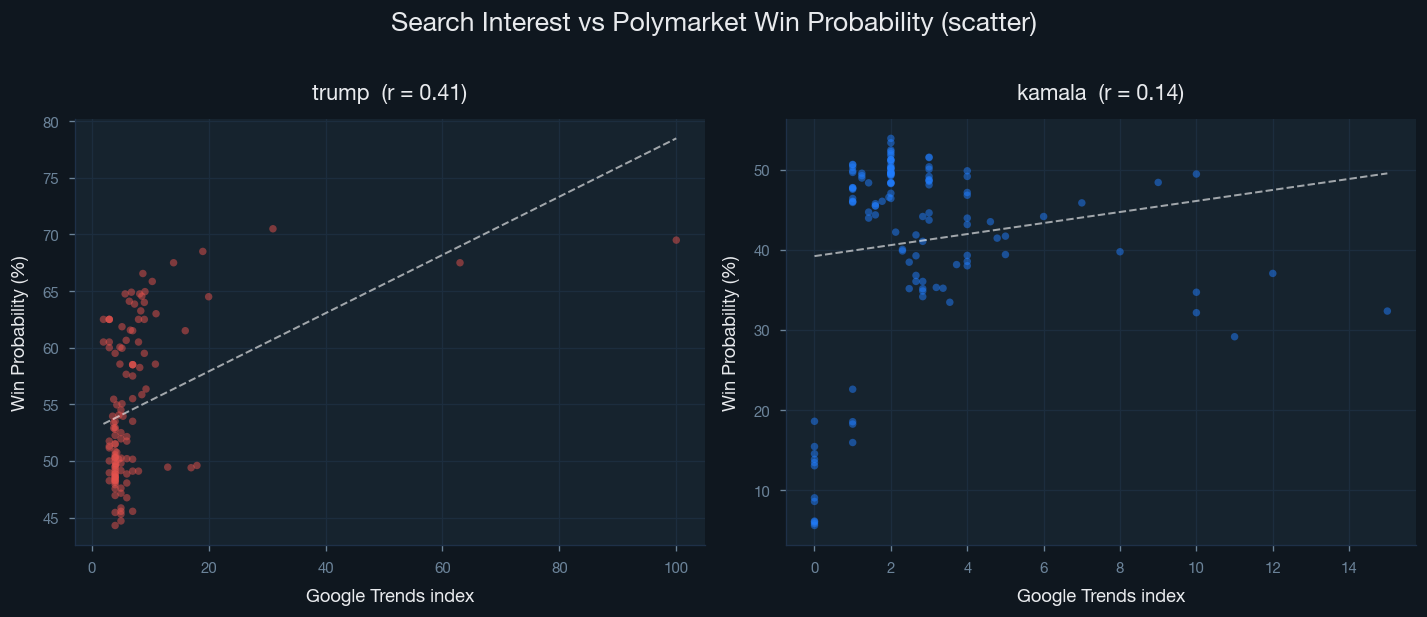

In [11]:
merged = df[['trump', 'kamala']].join(df_poly[['trump_price', 'harris_price']], how='inner')

print(f'Merged shape: {merged.shape}')
print(f'\nCorrelation matrix:')
print(merged.corr().round(3))

# ── Plot 1: Trends + Polymarket over time (dual axis) ────────────────────────
fig, axes = styled_fig(nrows=2, ncols=1, figsize=(14, 9),
                       title='Google Trends vs Polymarket Win Probability')

for ax, (search_kw, price_col, color) in zip(axes, [
    ('trump',  'trump_price',  REPUBLICAN),
    ('kamala', 'harris_price', DEMOCRAT),
]):
    ax2 = ax.twinx()

    ax.plot(merged.index, merged[search_kw], color=color, linewidth=1.5,
            alpha=0.7, label=f'Trends: {search_kw}')
    ax2.plot(merged.index, merged[price_col], color=color, linewidth=2,
             linestyle='--', alpha=0.95, label=f'Polymarket: {price_col}')

    style_ax(ax, ylabel='Search Interest (0–100)')
    ax2.set_ylabel('Win Probability (%)', color=TEXT_MUTED)
    ax2.tick_params(colors=TEXT_MUTED)
    ax2.set_facecolor(BG_PANEL)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_trends_vs_polymarket.png')
plt.show()

# ── Plot 2: Scatter — search interest vs win probability ────────────────────
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 5),
                       title='Search Interest vs Polymarket Win Probability (scatter)')

for ax, (search_kw, price_col, color) in zip(axes, [
    ('trump',  'trump_price',  REPUBLICAN),
    ('kamala', 'harris_price', DEMOCRAT),
]):
    ax.scatter(merged[search_kw], merged[price_col],
               color=color, alpha=0.5, s=20, edgecolors='none')

    # Trend line
    z = np.polyfit(merged[search_kw].dropna(), merged[price_col].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged[search_kw].min(), merged[search_kw].max(), 100)
    ax.plot(x_line, p(x_line), color='white', linewidth=1.2, linestyle='--', alpha=0.6)

    corr = merged[[search_kw, price_col]].corr().iloc[0, 1]
    style_ax(ax,
             title=f'{search_kw}  (r = {corr:.2f})',
             xlabel='Google Trends index',
             ylabel='Win Probability (%)')

plt.tight_layout()
plt.savefig(f'{BRONZE_PATH}plot_trends_polymarket_scatter.png')
plt.show()

## Summary

Key findings from the descriptive analysis:
- **Trump** — candidate that dominated search overall
- **Trump got shot** — events that caused the largest search spikes
- **Not necessarily very prominent correlation** — correlation direction between search interest and Polymarket odds